## 1. Load and merge data

In [1]:
import pandas as pd

data_train = pd.read_csv('data/train.csv')

data_train.head(5)

C:\Users\Raihan Maulana\AppData\Local\Temp\ipykernel_16952\2271600071.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data_train = pd.read_csv('data/train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [2]:
data_store = pd.read_csv('data/store.csv')

data_store.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [3]:
dataset = pd.merge(
    data_train,
    data_store,
    on='Store',
    how='left'
)

dataset.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 2. Data Cleanup

In [4]:
# 1. Filter hanya toko yang buka
dataset = dataset[dataset['Open'] == 1]

# 2. Pastikan Date terbaca sebagai datetime, lalu extract Month dan Year
dataset['Date'] = pd.to_datetime(dataset['Date'])
dataset['Month'] = dataset['Date'].dt.month
dataset['Year'] = dataset['Date'].dt.year

# 3. Buat kolom IsHoliday (binary) dari StateHoliday
dataset['IsHoliday'] = (dataset['StateHoliday'] != '0').astype(int)

# 4. Tentukan feature list (X) dan target (y)
features = ['DayOfWeek', 'Month', 'Promo', 'IsHoliday', 'SchoolHoliday', 'StoreType', 'Assortment']
target = 'Sales'

# Cek hasil akhir
dataset[features + [target, 'Date']].head()

,DayOfWeek,Month,Promo,IsHoliday,SchoolHoliday,StoreType,Assortment,Sales,Date
0,5,7,1,0,1,c,a,5263,2015-07-31
1,5,7,1,0,1,a,a,6064,2015-07-31
2,5,7,1,0,1,a,a,8314,2015-07-31
3,5,7,1,0,1,c,c,13995,2015-07-31
4,5,7,1,0,1,a,a,4822,2015-07-31


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[ns]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  object        
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  object        
 10  Assortment                 844392 non-null  object        
 11  CompetitionDistance        842206 non-null  float64     

## 3. Feature Engineering

In [6]:
# 1. Extract Month dan Year dari Date
dataset['Date'] = pd.to_datetime(dataset['Date'])
dataset['Month'] = dataset['Date'].dt.month
dataset['Year'] = dataset['Date'].dt.year

# 2. Buat IsHoliday (binary) dari StateHoliday
dataset['IsHoliday'] = (dataset['StateHoliday'] != '0').astype(int)

# 3. One-hot encoding untuk StoreType dan Assortment
dataset = pd.get_dummies(dataset, columns=['StoreType', 'Assortment'], drop_first=True)

# 4. Tentukan feature list (X) dan target (y)
features = ['DayOfWeek', 'Month', 'Promo', 'IsHoliday', 'SchoolHoliday'] + \
           [col for col in dataset.columns if col.startswith('StoreType_') or col.startswith('Assortment_')]

target = 'Sales'

# Cek hasil akhir
print(features)
dataset[features + [target, 'Date']].head()

['DayOfWeek', 'Month', 'Promo', 'IsHoliday', 'SchoolHoliday', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c']


,DayOfWeek,Month,Promo,IsHoliday,SchoolHoliday,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,Sales,Date
0,5,7,1,0,1,False,True,False,False,False,5263,2015-07-31
1,5,7,1,0,1,False,False,False,False,False,6064,2015-07-31
2,5,7,1,0,1,False,False,False,False,False,8314,2015-07-31
3,5,7,1,0,1,False,True,False,False,True,13995,2015-07-31
4,5,7,1,0,1,False,False,False,False,False,4822,2015-07-31


## 4. Train Test Split

In [7]:
# Tentukan cutoff date
cutoff_date = '2015-06-01'

train = dataset[dataset['Date'] < cutoff_date]
test = dataset[dataset['Date'] >= cutoff_date]

# Pisahkan X (features) dan y (target)
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# Cek ukuran dan rentang tanggal masing-masing
print("Train shape:", X_train.shape, "| Date range:", train['Date'].min(), "-", train['Date'].max())
print("Test shape:", X_test.shape, "| Date range:", test['Date'].min(), "-", test['Date'].max())

Train shape: (785781, 10) | Date range: 2013-01-01 00:00:00 - 2015-05-31 00:00:00
Test shape: (58611, 10) | Date range: 2015-06-01 00:00:00 - 2015-07-31 00:00:00


## 5. Train Linear Regression dan Random Forest

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 2. Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 3. Evaluasi kedua model
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_test, lr_preds, "Linear Regression")
evaluate(y_test, rf_preds, "Random Forest")

Linear Regression -> MAE: 1953.84, RMSE: 2709.45
Random Forest -> MAE: 1885.02, RMSE: 2660.99


## 6. IDENTIFY WHICH STORE/TIME FEATURES DRIVE LARGEST ERRORS

In [9]:
test_analysis = test.copy()
test_analysis['Predicted'] = rf_preds
test_analysis['Error'] = test_analysis['Sales'] - test_analysis['Predicted']
test_analysis['AbsError'] = test_analysis['Error'].abs()

# 1. Error rata-rata per Store, diurutkan dari yang paling besar
store_errors = test_analysis.groupby('Store')['AbsError'].mean().sort_values(ascending=False)
print("Top 10 stores dengan rata-rata error terbesar:")
print(store_errors.head(10))

print("\nTop 10 stores dengan rata-rata error terkecil:")
print(store_errors.tail(10))

# 2. Error rata-rata per DayOfWeek
dow_errors = test_analysis.groupby('DayOfWeek')['AbsError'].mean().sort_values(ascending=False)
print("\nError rata-rata per hari (1=Senin ... 7=Minggu):")
print(dow_errors)

# 3. Error rata-rata: Promo vs Non-Promo
promo_errors = test_analysis.groupby('Promo')['AbsError'].mean()
print("\nError rata-rata: Promo (1) vs Non-Promo (0):")
print(promo_errors)

# 4. Error rata-rata: Holiday vs Non-Holiday
holiday_errors = test_analysis.groupby('IsHoliday')['AbsError'].mean()
print("\nError rata-rata: Holiday (1) vs Non-Holiday (0):")
print(holiday_errors)

Top 10 stores dengan rata-rata error terbesar:
Store
1114    15193.469492
817     14844.768933
842     13714.780844
251     11926.436868
513     10864.221764
788     10536.111001
698     10395.957613
756     10017.359945
383      9654.016129
262      9636.694160
Name: AbsError, dtype: float64

Top 10 stores dengan rata-rata error terkecil:
Store
648     552.994509
1087    552.893025
602     545.237969
670     542.696113
352     537.070301
477     531.907753
144     531.378954
52      518.435927
638     497.705315
766     478.728138
Name: AbsError, dtype: float64

Error rata-rata per hari (1=Senin ... 7=Minggu):
DayOfWeek
7    2760.922557
1    2173.827087
2    1951.772753
6    1815.990457
5    1812.550027
3    1804.449074
4    1709.269783
Name: AbsError, dtype: float64

Error rata-rata: Promo (1) vs Non-Promo (0):
Promo
0    1620.395792
1    2191.404837
Name: AbsError, dtype: float64

Error rata-rata: Holiday (1) vs Non-Holiday (0):
IsHoliday
0    1884.845671
1    2000.660070
Name: AbsE

In [13]:
# Bandingkan statistik Sales kedua store
print("=== Store 1114 (error terbesar) ===")
print(dataset[dataset['Store'] == 1114]['Sales'].describe())

print("\n=== Store 766 (error terkecil) ===")
print(dataset[dataset['Store'] == 766]['Sales'].describe())

# Bandingkan metadata dari store.csv
print("\n=== Metadata Store 1114 ===")
print(data_store[data_store['Store'] == 1114])

print("\n=== Metadata Store 766 ===")
print(data_store[data_store['Store'] == 766])

=== Store 1114 (error terbesar) ===
count      784.000000
mean     20666.562500
std       3452.938601
min       8880.000000
25%      18366.500000
50%      20412.500000
75%      22350.000000
max      35697.000000
Name: Sales, dtype: float64

=== Store 766 (error terkecil) ===
count      622.000000
mean      6123.943730
std       1446.240141
min       1739.000000
25%       5106.750000
50%       5964.000000
75%       6960.250000
max      12756.000000
Name: Sales, dtype: float64

=== Metadata Store 1114 ===
      Store StoreType Assortment  CompetitionDistance  \
1113   1114         a          c                870.0   

      CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
1113                        NaN                       NaN       0   

      Promo2SinceWeek  Promo2SinceYear PromoInterval  
1113              NaN              NaN           NaN  

=== Metadata Store 766 ===
     Store StoreType Assortment  CompetitionDistance  \
765    766         d          c            

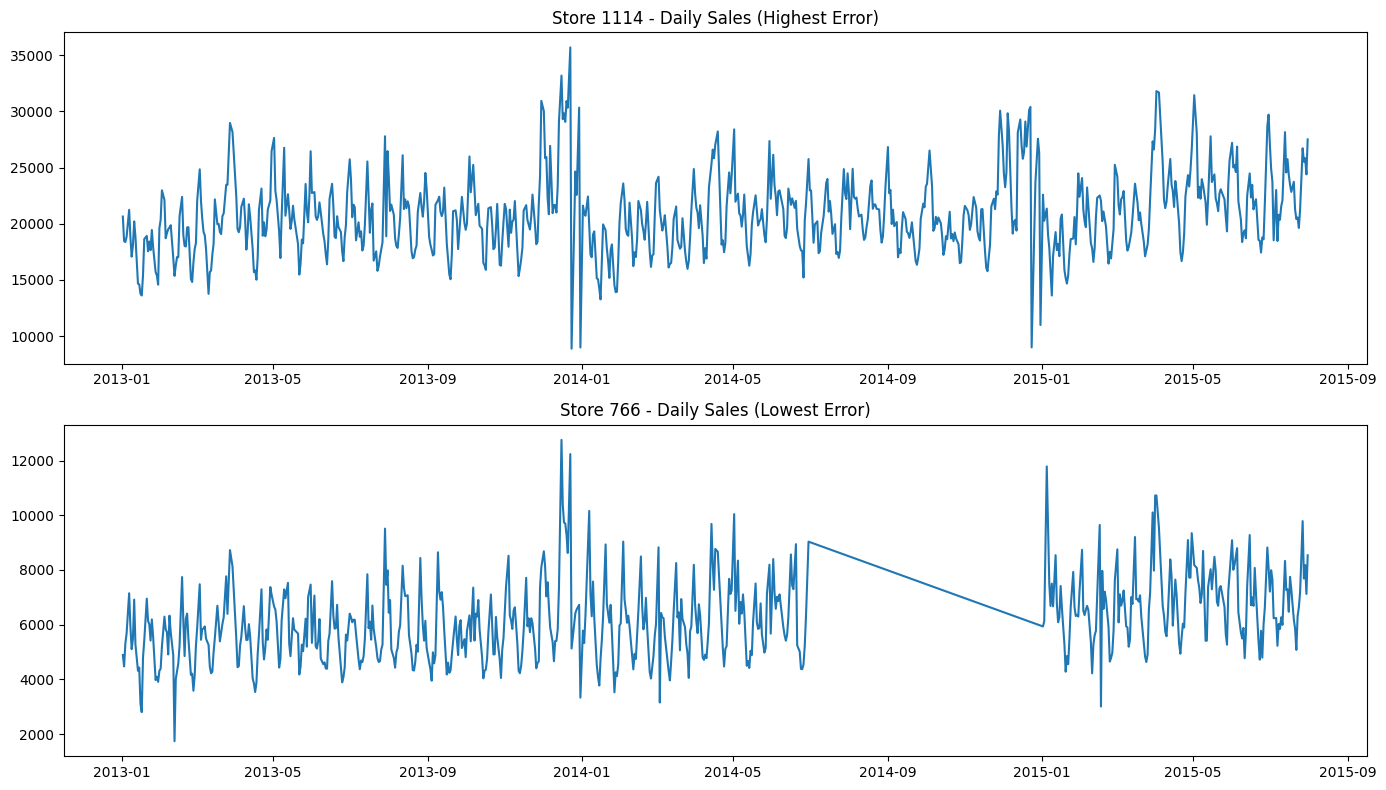

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

store_1114 = dataset[dataset['Store'] == 1114].sort_values('Date')
store_766 = dataset[dataset['Store'] == 766].sort_values('Date')

axes[0].plot(store_1114['Date'], store_1114['Sales'])
axes[0].set_title('Store 1114 - Daily Sales (Highest Error)')

axes[1].plot(store_766['Date'], store_766['Sales'])
axes[1].set_title('Store 766 - Daily Sales (Lowest Error)')

plt.tight_layout()
plt.show()

## 7. VISUALIZE ACTUAL VS PREDICTED SALES

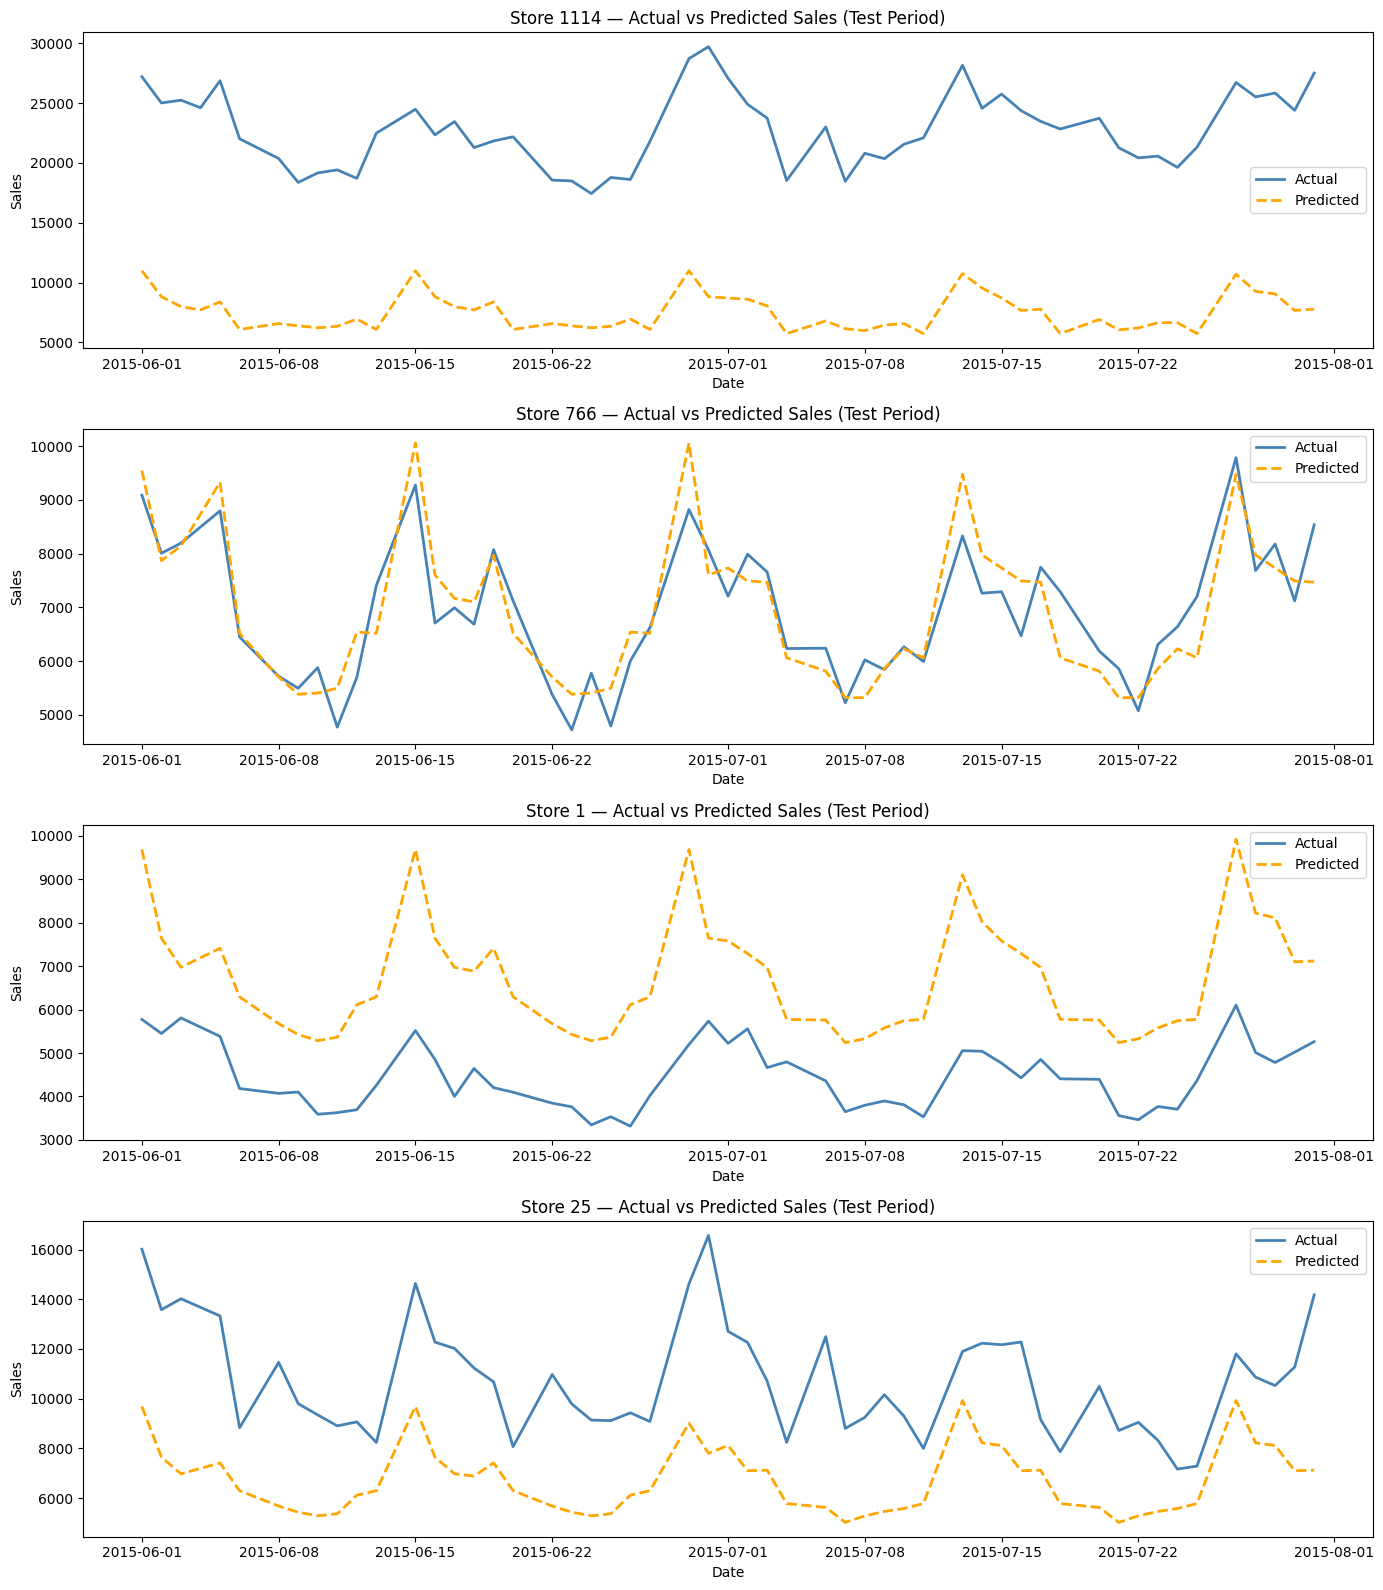

In [14]:
import matplotlib.pyplot as plt

test_analysis = test.copy()
test_analysis['Predicted'] = rf_preds

# Pilih beberapa store untuk divisualisasikan
sample_stores = [1114, 766, 1, 25]
fig, axes = plt.subplots(len(sample_stores), 1, figsize=(14, 4 * len(sample_stores)))

for i, store_id in enumerate(sample_stores):
    store_data = test_analysis[test_analysis['Store'] == store_id].sort_values('Date')
    
    axes[i].plot(store_data['Date'], store_data['Sales'], label='Actual', color='steelblue', linewidth=2)
    axes[i].plot(store_data['Date'], store_data['Predicted'], label='Predicted', color='orange', linestyle='--', linewidth=2)
    axes[i].set_title(f'Store {store_id} — Actual vs Predicted Sales (Test Period)')
    axes[i].legend()
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Sales')

plt.tight_layout()
plt.show()